# Librerías

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# Librerías adicionales utilizadas
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split,  cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.mixture import GaussianMixture
import seaborn as sns
from sklearn.metrics import silhouette_score

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
import joblib

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone



# Clusters con GMM

## Obtenemos del dataset filtrado y lo dividmos en variables objetivo, de tratamiento y confusoras

In [190]:
!wget -q https://raw.githubusercontent.com/ClemoAcevedo/hsls09-causal-impact/refs/heads/main/Entrega%20Avance/hsls09_master_clean.csv

In [191]:
df_master_clean = pd.read_csv("hsls09_master_clean.csv")

In [192]:
df_master_clean.head()

,STU_ID,X3TGPA9TH,X1TXMTH,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,X1PAR1EMP,X1SEX,X1RACE,...,X1SEX_1.0,X1SEX_2.0,X1RACE_1.0,X1RACE_2.0,X1RACE_3.0,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0
0,10001,3.5,0.8304,5.0,10.0,0.0,0.0,4.0,1.0,8.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,10002,4.0,-0.2956,3.0,3.0,0.0,0.0,3.0,2.0,8.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,10003,3.5,1.2997,7.0,6.0,0.0,0.0,4.0,2.0,3.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,10004,3.5,-0.1427,4.0,5.0,0.0,0.0,2.0,2.0,8.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,10005,3.5,1.1405,4.0,9.0,0.0,0.0,4.0,1.0,8.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [193]:
# Usamos el df_master_clean cargado al final de la Parte 2
tratamiento = ['X3TCREDADV', 'X3TCREDHON', 'X5DUALCRSFLG', 'A1G9STUDY']
features_X = [
    # confusores
    'X3TGPA9TH', 'X1TXMTH',
    'X1PAREDU', 'X1FAMINCOME', 'X1POVERTY', 'X1POVERTY130', 'X1PAR1EMP', 'X1STDOB',

    # dummies de sexo
    'X1SEX_1.0', 'X1SEX_2.0',

    # dummies de raza
    'X1RACE_1.0', 'X1RACE_2.0', 'X1RACE_3.0', 'X1RACE_4.0',
    'X1RACE_5.0', 'X1RACE_6.0', 'X1RACE_7.0', 'X1RACE_8.0'
]

# Eliminar filas donde el tratamiento u objetivo tienen NaN
df_model = df_master_clean.dropna(subset=['X3TGPAACAD'])
df_model = df_model.dropna(subset=tratamiento)

# Variable Objetivo
y = df_model['X3TGPAACAD']

# Variables de tratamiento
t = df_model[tratamiento]

# Variables confusoras
X = df_model[features_X]

print(f"Dataset listo para modelar (filas sin NaN en target): {df_model.shape}")
print(f"Dimensiones de X (confusoras): {X.shape}")
print(f"Dimensiones de y (objetivo): {y.shape}")
print(f"Dimensiones de t (tratamiento): {t.shape}")
print(f"Total de features: {len(features_X)}")

Dataset listo para modelar (filas sin NaN en target): (10714, 31)
Dimensiones de X (confusoras): (10714, 18)
Dimensiones de y (objetivo): (10714,)
Dimensiones de t (tratamiento): (10714, 4)
Total de features: 18


In [194]:
# primero, revisamos si X tiene nulos que necesiten cuidado
nulos_en_x = X.isnull().sum()
nulos_en_x = nulos_en_x[nulos_en_x > 0].sort_values(ascending=False)

if nulos_en_x.empty:
    print("No se encontraron NaNs en las features (X).")
else:
    print("Features con NaNs que requieren imputación:")
    print(nulos_en_x)
    print("\n")

Features con NaNs que requieren imputación:
X1POVERTY130    2371
X1POVERTY       2371
X1FAMINCOME     2360
X1PAR1EMP       2358
X1PAREDU        2351
X1TXMTH          761
X3TGPA9TH        286
X1STDOB           68
dtype: int64




In [195]:
# Imputamos y escalamos con minmaxscaler las variables confusoiras

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)

print("Datos imputados (NaNs rellenados con la mediana).")

scaler = MinMaxScaler()

X_ready = scaler.fit_transform(X_imputed)

print("Datos escalados con MinMaxScaler.")
print("\nPrimeras 5 filas de X_train_scaled (verificación):")
print(X_ready[:5])

Datos imputados (NaNs rellenados con la mediana).
Datos escalados con MinMaxScaler.

Primeras 5 filas de X_train_scaled (verificación):
[[0.86666667 0.60512747 0.66666667 0.75       0.         0.
  1.         0.73658537 1.         0.         0.         0.
  0.         0.         0.         0.         0.         1.        ]
 [1.         0.40283143 0.33333333 0.16666667 0.         0.
  0.66666667 0.75853659 0.         1.         0.         0.
  0.         0.         0.         0.         0.         1.        ]
 [0.86666667 0.68944144 1.         0.41666667 0.         0.
  1.         0.74634146 0.         1.         0.         0.
  1.         0.         0.         0.         0.         0.        ]
 [0.73333333 0.58360432 0.33333333 0.33333333 0.         0.
  1.         0.74146341 0.         1.         0.         0.
  0.         0.         0.         0.         0.         1.        ]
 [0.6        0.43423582 0.16666667 0.25       0.         0.
  1.         0.5097561  0.         1.         0.

## Aplicar GMM

In [196]:
# Rango de valores de K a evaluar
n_range = range(2, 10)

aic_values = []
bic_values = []

for k in n_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=86
    )
    gmm.fit(X_ready)
    labels = gmm.predict(X_ready)

    aic_values.append(gmm.aic(X_ready))
    bic_values.append(gmm.bic(X_ready))

    sil = silhouette_score(X_ready, labels)
    print(f"Silhouette Score (K={k}): {sil:.4f}")

print("AIC:", aic_values)
print("BIC:", bic_values)

Silhouette Score (K=2): 0.2553
Silhouette Score (K=3): 0.3094
Silhouette Score (K=4): 0.3387
Silhouette Score (K=5): 0.3586
Silhouette Score (K=6): 0.3825
Silhouette Score (K=7): 0.3929
Silhouette Score (K=8): 0.4000
Silhouette Score (K=9): 0.3750
AIC: [np.float64(-697639.0524568603), np.float64(-644160.6944640843), np.float64(-899448.4243488369), np.float64(-999936.2063698196), np.float64(-1066943.0844141913), np.float64(-1105498.9788816932), np.float64(-1202134.8067692877), np.float64(-1229592.4108817303)]
BIC: [np.float64(-694880.1952643892), np.float64(-640018.7690220894), np.float64(-893923.4306573182), np.float64(-993028.1444287772), np.float64(-1058651.9542236251), np.float64(-1095824.7804416032), np.float64(-1191077.540079674), np.float64(-1217152.0759425927)]


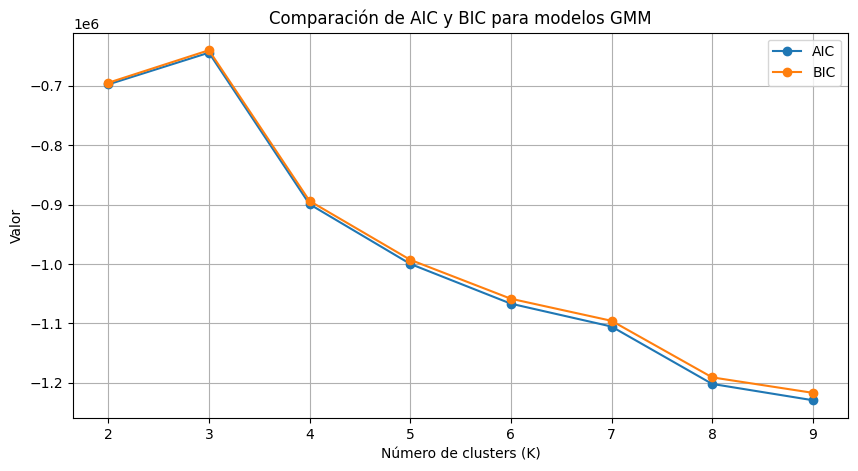

In [197]:
# Graficamos AIC Y BIC
plt.figure(figsize=(10,5))
plt.plot(n_range, aic_values, marker='o', label='AIC')
plt.plot(n_range, bic_values, marker='o', label='BIC')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Valor")
plt.title("Comparación de AIC y BIC para modelos GMM")
plt.legend()
plt.grid(True)
plt.show()

Vemos que para k=8 se los valores de AIC y BIC empiezan a decrecer más lento, además de ser un máximo local para Silhouette Score, por lo que usamos ese valor

In [198]:
# Aplicar GMM

gm = GaussianMixture(n_components=8, random_state=86, covariance_type="full")
gm.fit(X_ready)
labels = gm.predict(X_ready)
probs = gm.predict_proba(X_ready)

In [199]:
(unique, counts) = np.unique(labels, return_counts=True)
print(f'Datos por cluster: {list(zip(unique, counts))}')

print(f'Probabilidades de pertetencia {probs[:5]}')

Datos por cluster: [(np.int64(0), np.int64(2909)), (np.int64(1), np.int64(1872)), (np.int64(2), np.int64(624)), (np.int64(3), np.int64(2580)), (np.int64(4), np.int64(415)), (np.int64(5), np.int64(332)), (np.int64(6), np.int64(1178)), (np.int64(7), np.int64(804))]
Probabilidades de pertetencia [[0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]]


Vemos que ningun Cluster de los formados tiene menos de 300 datos, por lo que 8 clusters es un buen número para dividir los datos

In [200]:
# Agregamos los clusters a los datos

df_clustered = df_model.copy()
df_clustered["Cluster"] = labels

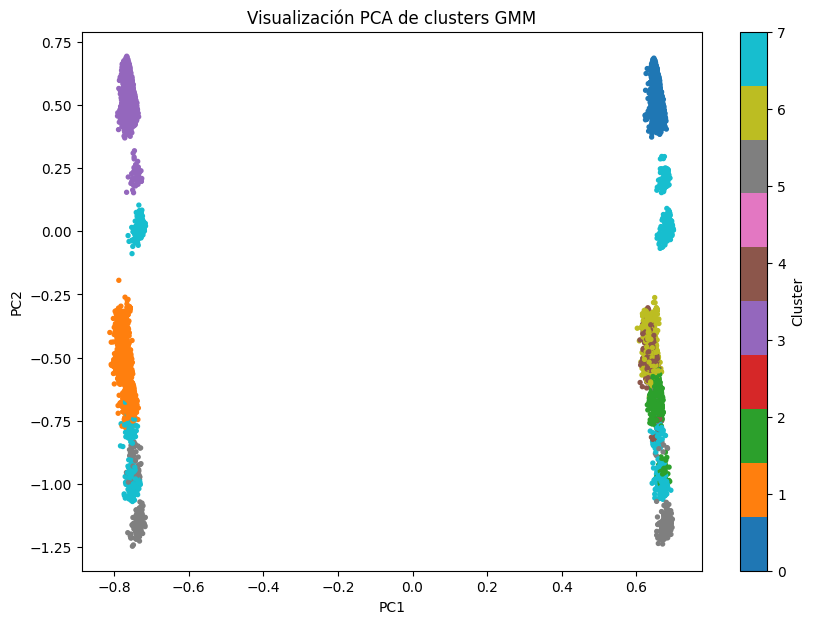

In [201]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_ready)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=8, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA de clusters GMM")
plt.colorbar(label="Cluster")
plt.show()

## Análisis de Clusters

In [202]:
cols_resumen = features_X + tratamiento + ['X3TGPAACAD']

cluster_summary = df_clustered.groupby("Cluster")[cols_resumen].mean()

print("---------------- Estadísticas por Cluster (Media) ----------------")
display(cluster_summary)


---------------- Estadísticas por Cluster (Media) ----------------


,X3TGPA9TH,X1TXMTH,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,X1PAR1EMP,X1STDOB,X1SEX_1.0,X1SEX_2.0,...,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0,X3TCREDADV,X3TCREDHON,X5DUALCRSFLG,A1G9STUDY,X3TGPAACAD
Cluster,,,,,,,,,,,,,,,,,,,,,
0,3.279070,0.347140,3.791805,5.945756,0.000000,0.000000,3.418287,199473.818307,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2.742351,3.308697,2.693022,0.411825,3.176607
1,2.882735,0.337647,3.830833,5.494147,0.000000,0.000000,3.468280,199466.373175,1.000000,0.000000,...,0.024573,0.240385,0.198184,0.008547,0.000000,2.925481,2.667468,2.811432,0.424679,2.720085
2,2.965686,0.062292,3.158111,4.722793,0.000000,0.096509,3.365503,199471.895833,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,2.357372,2.709135,2.770833,0.341346,2.865385
3,3.046509,0.418857,3.882567,6.084815,0.000000,0.024658,3.444647,199462.837995,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2.612984,2.767829,2.739147,0.425194,2.889729
4,3.026382,0.230561,3.656442,5.119632,0.000000,0.064417,3.411043,199472.212560,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,2.975904,2.804819,2.739759,0.395181,2.924699
5,2.502329,-0.222803,2.066265,1.599398,0.828313,1.000000,2.813253,199453.036145,0.533133,0.466867,...,0.057229,0.885542,0.000000,0.027108,0.000000,1.765060,1.540663,2.789157,0.331325,2.477410
6,3.134045,0.331232,4.078203,5.658902,0.000000,0.000000,3.457286,199472.666376,0.000000,1.000000,...,0.046689,0.000000,0.000000,0.013582,0.000000,3.217317,3.296265,2.786078,0.461800,3.007640
7,2.862821,0.046948,2.589552,1.603234,0.756219,1.000000,2.880597,199458.613466,0.401741,0.598259,...,0.000000,0.000000,0.134328,0.000000,0.467662,1.978856,1.927861,2.758706,0.425373,2.727612


In [203]:
print("---------------- Tamaño de cada cluster ----------------")
print(df_clustered["Cluster"].value_counts().sort_index())

---------------- Tamaño de cada cluster ----------------
Cluster
0    2909
1    1872
2     624
3    2580
4     415
5     332
6    1178
7     804
Name: count, dtype: int64


In [204]:
cluster_profile = df_clustered.groupby("Cluster")[cols_resumen].agg(["mean", "std"])
display(cluster_profile)


cluster_norm = df_clustered.groupby("Cluster")[cols_resumen].mean()
cluster_norm = (cluster_norm - cluster_norm.mean()) / cluster_norm.std()
display(cluster_norm)

X3TGPA9TH             X1TXMTH            X1PAREDU            \
             mean       std      mean       std      mean       std   
Cluster                                                               
0        3.279070  0.656131  0.347140  0.829240  3.791805  1.435180   
1        2.882735  0.800186  0.337647  1.016668  3.830833  1.551092   
2        2.965686  0.718335  0.062292  0.868832  3.158111  1.447877   
3        3.046509  0.699911  0.418857  0.865729  3.882567  1.451352   
4        3.026382  0.805128  0.230561  0.856980  3.656442  1.506419   
5        2.502329  0.867258 -0.222803  0.831814  2.066265  1.102787   
6        3.134045  0.770985  0.331232  1.046647  4.078203  1.618294   
7        2.862821  0.802513  0.046948  0.900625  2.589552  1.115135   

        X1FAMINCOME           X1POVERTY            ... X3TCREDADV            \
               mean       std      mean       std  ...       mean       std   
Cluster                                            ...                        
0          5.945756  2.949021  0.000000  0.000000  ...   2.742351  3.354314   
1          5.494147  2.945951  0.000000  0.000000  ...   2.925481  3.819613   
2          4.722793  2.708612  0.000000  0.000000  ...   2.357372  3.057713   
3          6.084815  3.087547  0.000000  0.000000  ...   2.612984  3.351301   
4          5.119632  2.790277  0.000000  0.000000  ...   2.975904  3.693825   
5          1.599398  0.537758  0.828313  0.377677  ...   1.765060  2.966416   
6          5.658902  3.044962  0.000000  0.000000  ...   3.217317  3.904430   
7          1.603234  0.590957  0.756219  0.429629  ...   1.978856  2.979515   

        X3TCREDHON           X5DUALCRSFLG           A1G9STUDY            \
              mean       std         mean       std      mean       std   
Cluster                                                                   
0         3.308697  4.543739     2.693022  0.514196  0.411825  0.492248   
1         2.667468  4.119328     2.811432  0.437692  0.424679  0.494426   
2         2.709135  4.064776     2.770833  0.460701  0.341346  0.474542   
3         2.767829  4.233603     2.739147  0.482917  0.425194  0.494468   
4         2.804819  4.141865     2.739759  0.486270  0.395181  0.489480   
5         1.540663  3.085489     2.789157  0.470395  0.331325  0.471400   
6         3.296265  4.470768     2.786078  0.445969  0.461800  0.498750   
7         1.927861  3.600248     2.758706  0.500546  0.425373  0.494707   

        X3TGPAACAD            
              mean       std  
Cluster                       
0         3.176607  0.643072  
1         2.720085  0.764517  
2         2.865385  0.668234  
3         2.889729  0.701257  
4         2.924699  0.728076  
5         2.477410  0.736316  
6         3.007640  0.728665  
7         2.727612  0.772219  

[8 rows x 46 columns]

,X3TGPA9TH,X1TXMTH,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,X1PAR1EMP,X1STDOB,X1SEX_1.0,X1SEX_2.0,...,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0,X3TCREDADV,X3TCREDHON,X5DUALCRSFLG,A1G9STUDY,X3TGPAACAD
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.379326,0.708055,0.572690,0.762742,-0.539318,-0.607219,0.501160,0.964936,-0.829576,0.829576,...,-0.672305,-0.622168,-0.482159,-0.620207,1.515506,0.337583,1.108379,-1.834475,0.217746,1.559491
1,-0.347257,0.664171,0.627194,0.519680,-0.539318,-0.607219,0.685487,-0.007650,1.431716,-1.431716,...,0.356270,-0.059366,0.091531,0.241069,-0.675981,0.700309,0.064508,1.360168,0.505262,-0.611318
2,0.014111,-0.608828,-0.312278,0.104526,-0.539318,-0.392714,0.306543,0.713796,-0.829576,0.829576,...,-0.672305,1.719091,-0.482159,-0.620207,-0.675981,-0.424949,0.132338,0.264846,-1.358702,0.079595
3,0.366206,1.039615,0.699442,0.837586,-0.539318,-0.552415,0.598349,-0.469463,1.431716,-1.431716,...,-0.672305,-0.622168,-0.482159,-0.620207,1.515506,0.081345,0.227888,-0.590028,0.516765,0.195354
4,0.278524,0.169099,0.383652,0.318110,-0.539318,-0.464043,0.474450,0.755171,-0.829576,0.829576,...,-0.672305,-0.622168,2.412577,-0.620207,-0.675981,0.800182,0.288105,-0.573523,-0.154554,0.361640
5,-2.004445,-1.926857,-1.837067,-1.576531,1.716107,1.615415,-1.729619,-1.749916,0.375993,-0.375993,...,1.723215,1.451115,-0.482159,2.111489,-0.675981,-1.598144,-1.769843,0.759200,-1.582844,-1.765268
6,0.747546,0.634513,0.972652,0.608353,-0.539318,-0.607219,0.644951,0.814455,-0.829576,0.829576,...,1.282042,-0.622168,-0.482159,0.748476,-0.675981,1.278352,1.088140,0.676143,1.335549,0.756035
7,-0.434011,-0.679768,-1.106284,-1.574466,1.519800,1.615415,-1.481320,-1.021329,0.078879,-0.078879,...,-0.672305,-0.622168,-0.093314,-0.620207,0.348894,-1.174678,-1.139515,-0.062331,0.520777,-0.575529


Resumen del contenido de cada Cluster


In [205]:
for c in sorted(df_clustered["Cluster"].unique()):
    print(f"\n-------------- Cluster {c} --------------")

    temp = cluster_summary.loc[c]

    print(f"- Tamaño: {df_clustered[df_clustered['Cluster']==c].shape[0]} estudiantes")

    # Confusores
    print("\nConfusores relevantes:")
    for var in features_X:
        valor = temp[var]
        if valor > df_clustered[var].mean():
            print(f"  - {var}: más alto que el promedio")
        else:
            print(f"  - {var}: más bajo que el promedio")

    # Tratamiento
    print("\nTratamientos:")
    for var in tratamiento:
        valor = temp[var]
        promedio = df_clustered[var].mean()
        print(f"  - {var}: {valor:.3f} (promedio={promedio:.3f})")

    # Outcome
    print(f"\nRendimiento académico (GPA X3TGPAACAD): {temp['X3TGPAACAD']:.3f}")


-------------- Cluster 0 --------------
- Tamaño: 2909 estudiantes

Confusores relevantes:
  - X3TGPA9TH: más alto que el promedio
  - X1TXMTH: más alto que el promedio
  - X1PAREDU: más alto que el promedio
  - X1FAMINCOME: más alto que el promedio
  - X1POVERTY: más bajo que el promedio
  - X1POVERTY130: más bajo que el promedio
  - X1PAR1EMP: más alto que el promedio
  - X1STDOB: más alto que el promedio
  - X1SEX_1.0: más bajo que el promedio
  - X1SEX_2.0: más alto que el promedio
  - X1RACE_1.0: más bajo que el promedio
  - X1RACE_2.0: más bajo que el promedio
  - X1RACE_3.0: más bajo que el promedio
  - X1RACE_4.0: más bajo que el promedio
  - X1RACE_5.0: más bajo que el promedio
  - X1RACE_6.0: más bajo que el promedio
  - X1RACE_7.0: más bajo que el promedio
  - X1RACE_8.0: más alto que el promedio

Tratamientos:
  - X3TCREDADV: 2.742 (promedio=2.694)
  - X3TCREDHON: 3.309 (promedio=2.852)
  - X5DUALCRSFLG: 2.693 (promedio=2.749)
  - A1G9STUDY: 0.412 (promedio=0.417)

Rendimi

# Parte 5: Optimización del modelo de traTamiEnTO (Random Forest)

In [206]:
y = df_clustered['X3TGPAACAD']

data = df_clustered[tratamiento + features_X + ['Cluster']].copy()
# Binarizar
data.loc[:, "T_ADV"] = (data["X3TCREDADV"] >= 4).astype(int)
data.loc[:, "T_HON"] = (data["X3TCREDHON"] >= 4).astype(int)
data.loc[:, "T_STUDY"] = data["A1G9STUDY"].astype(int)

# Comprobación
for col in ["T_ADV","T_HON","T_STUDY"]:
    print(col, data[col].value_counts(normalize=True))


T_ADV T_ADV
0    0.730819
1    0.269181
Name: proportion, dtype: float64
T_HON T_HON
0    0.718219
1    0.281781
Name: proportion, dtype: float64
T_STUDY T_STUDY
0    0.583442
1    0.416558
Name: proportion, dtype: float64


In [207]:
# Confounders
X = data[features_X].copy()

# Tratamientos binarios que quieres modelar
vars_treat = ["T_ADV", "T_HON", "T_STUDY"]

# Diccionarios para guardar resultados
best_models = {}
oof_probs_dict = {}


In [208]:
print(data["Cluster"].value_counts().sort_index())  # si ya tienes clusters
for col in ["T_ADV","T_HON","T_STUDY"]:
    print(col, data.groupby("Cluster")[col].sum())  # cuántos tratados por cluster

Cluster
0    2909
1    1872
2     624
3    2580
4     415
5     332
6    1178
7     804
Name: count, dtype: int64
T_ADV Cluster
0    814
1    541
2    144
3    663
4    123
5     52
6    394
7    153
Name: T_ADV, dtype: int64
T_HON Cluster
0    945
1    482
2    176
3    719
4    108
5     56
6    383
7    150
Name: T_HON, dtype: int64
T_STUDY Cluster
0    1198
1     795
2     213
3    1097
4     164
5     110
6     544
7     342
Name: T_STUDY, dtype: int64


In [209]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preproc = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [210]:
def tune_propensity_model(X, y, preproc, random_state=86):

    rf = RandomForestClassifier(
        random_state=random_state,
        class_weight="balanced"
    )

    pipe = Pipeline([
        ("preproc", preproc),
        ("rf", rf)
    ])

    param_grid = {
        "rf__n_estimators": [100, 200],
        "rf__max_depth": [5, 10, None],
        "rf__min_samples_leaf": [5, 10],
        "rf__max_features": ["sqrt"]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X, y)

    return grid


In [211]:
for var in vars_treat:

    print(f"\n=========== Tratamiento: {var} ===========")
    y_t = data[var]

    grid = tune_propensity_model(X, y_t, preproc)

    print("Mejor AUC CV:", grid.best_score_)
    print("Mejores parámetros:", grid.best_params_)

    best_models[var] = grid.best_estimator_



=========== Tratamiento: T_ADV ===========
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejor AUC CV: 0.7772084111409431
Mejores parámetros: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 10, 'rf__n_estimators': 200}

=========== Tratamiento: T_HON ===========
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejor AUC CV: 0.7554545897184587
Mejores parámetros: {'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 200}

=========== Tratamiento: T_STUDY ===========
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejor AUC CV: 0.5224287255283877
Mejores parámetros: {'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 10, 'rf__n_estimators': 200}



=========== Probabilidades OOF para T_ADV ===========
AUC OOF: 0.7769379170408631
Brier: 0.18571017800221645


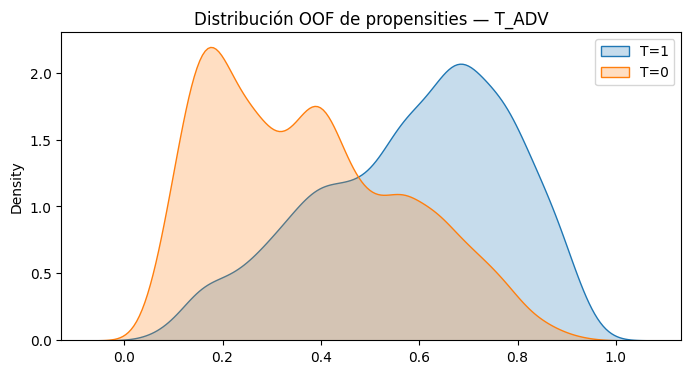


=========== Probabilidades OOF para T_HON ===========
AUC OOF: 0.754853375018644
Brier: 0.20320939769579752


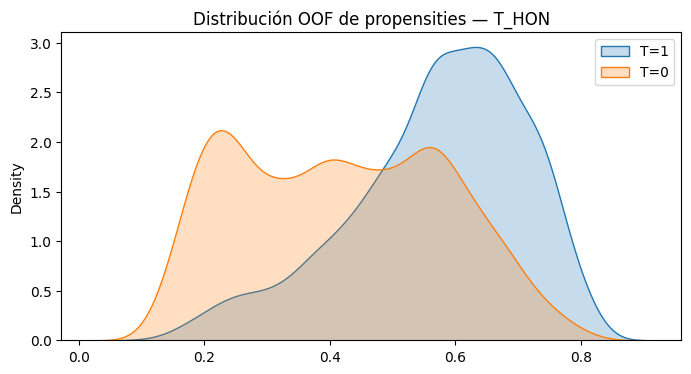


=========== Probabilidades OOF para T_STUDY ===========
AUC OOF: 0.5222558699369024
Brier: 0.24924409510824794


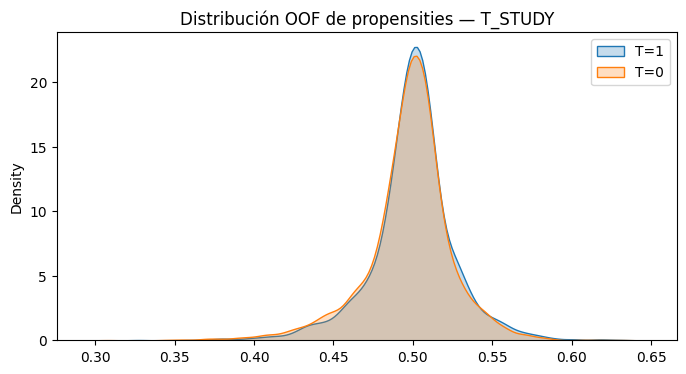

In [212]:
for var in vars_treat:
    print(f"\n=========== Probabilidades OOF para {var} ===========")

    model = best_models[var]
    y_t = data[var]

    oof_probs = cross_val_predict(
        model,
        X,
        y_t,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=86),
        method="predict_proba",
        n_jobs=-1
    )

    oof_p1 = oof_probs[:, 1]
    oof_probs_dict[var] = oof_p1

    print("AUC OOF:", roc_auc_score(y_t, oof_p1))
    print("Brier:", brier_score_loss(y_t, oof_p1))

    # Distribución para inspección
    plt.figure(figsize=(8,4))
    sns.kdeplot(oof_p1[y_t==1], label="T=1", fill=True)
    sns.kdeplot(oof_p1[y_t==0], label="T=0", fill=True)
    plt.title(f"Distribución OOF de propensities — {var}")
    plt.legend()
    plt.show()


Vemos que T_STUDY tiene un AUC muy cercano a 0.5, esto implica que el modelo no discrimina entre tratados y no tratados

Además las curvas KDE totalmente solapadas confirman esto visualmente

Por lo tanto, no sirve como propensity model confiable

Por lo que no se incluirá en la data para DML

In [214]:
# Solo los tratamientos con modelos decentes
valid_treatments = ["T_ADV", "T_HON"]

for var in valid_treatments:
    data[f"{var}_hat"] = oof_probs_dict[var]


Ahora DATA contiene:

Confusores (features_X)

Tratamientos binarios (T_ADV, T_HON)

Clusters (Cluster)

Propensities predichas (T_ADV_hat, T_HON_hat)


In [215]:
data.head()

,X3TCREDADV,X3TCREDHON,X5DUALCRSFLG,A1G9STUDY,X3TGPA9TH,X1TXMTH,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,...,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0,Cluster,T_ADV,T_HON,T_STUDY,T_ADV_hat,T_HON_hat
0,3.0,0.0,3.0,0.0,3.5,0.8304,5.0,10.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3,0,0,0,0.635951,0.648165
1,0.0,0.0,3.0,0.0,4.0,-0.2956,3.0,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,0,0.403239,0.429158
2,6.0,4.0,3.0,0.0,3.5,1.2997,7.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6,1,1,0,0.768026,0.735257
5,1.0,0.0,2.0,0.0,3.0,0.7106,3.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,0,0.419073,0.513757
6,4.0,0.0,3.0,1.0,2.5,-0.1208,2.0,4.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,1,0,1,0.199276,0.238200


In [216]:
# Guardar el dataframe completo en CSV
from google.colab import files

data.to_csv("dataDML.csv", index=False)
files.download("dataDML.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>